# Ginzburg–Landau Free Energy Functional

The **Ginzburg–Landau (GL)** theory is a phenomenological framework that describes
superconductivity near the critical temperature $T_c$ through a complex order
parameter $\psi(\mathbf{r})$. Its power lies in capturing spatially inhomogeneous
phenomena — vortices, domain walls, surface superconductivity — without requiring
a full microscopic solution.

## The Order Parameter

The superconducting state is described by a complex scalar field
$\psi(\mathbf{r}) = |\psi|\, e^{i\varphi}$, where:

- $|\psi(\mathbf{r})|^2$ is proportional to the superfluid density $n_s$
- $\varphi(\mathbf{r})$ is the macroscopic quantum phase
- The supercurrent is $\mathbf{J}_s \propto |\psi|^2 \nabla\varphi$

Near $T_c$, $|\psi|$ is small and the free energy can be expanded as a
power series — this is the Landau expansion.

## Free Energy Functional

The GL free energy density (in Gaussian units) is:

$$
f_s - f_n = \alpha\, |\psi|^2 + \frac{\beta}{2}\, |\psi|^4
+ \frac{1}{2m^*} \left| \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right) \psi \right|^2
+ \frac{|\mathbf{B}|^2}{8\pi}
$$

The four terms represent:

| Term | Physical meaning |
|------|------------------|
| $\alpha \|\psi\|^2$ | Condensation energy; $\alpha < 0$ below $T_c$ |
| $\frac{\beta}{2}\|\psi\|^4$ | Stabilization (prevents $\|\psi\| \to \infty$) |
| Gradient term | Kinetic energy of supercurrents |
| $\|\mathbf{B}\|^2 / 8\pi$ | Magnetic field energy |

The temperature dependence enters through $\alpha(T) = \alpha_0 (T - T_c) / T_c$,
which changes sign at $T_c$.

## GL Equations

Minimizing the free energy functional $F = \int f\, d^3r$ with respect to
$\psi^*$ and $\mathbf{A}$ yields two coupled PDEs.

### First GL Equation (order parameter)

$$
\alpha\,\psi + \beta\,|\psi|^2 \psi
+ \frac{1}{2m^*} \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right)^{\!2} \psi = 0
$$

This is a nonlinear Schrödinger equation for the order parameter.

### Second GL Equation (supercurrent)

$$
\mathbf{J}_s = \frac{e^*}{m^*} \operatorname{Re}\!\left[
\psi^* \left( -i\hbar\nabla - \frac{2e}{c}\mathbf{A} \right) \psi
\right]
$$

Combined with Maxwell's equation $\nabla \times \mathbf{B} = \frac{4\pi}{c}\mathbf{J}_s$,
this yields the Meissner screening.

## Characteristic Lengths

Two fundamental length scales emerge from GL theory:

**Coherence length** (scale over which $\psi$ varies):
$$
\xi_{\text{GL}}(T) = \sqrt{\frac{\hbar^2}{2m^* |\alpha(T)|}}
= \frac{\xi_{\text{GL}}(0)}{\sqrt{1 - T/T_c}}
$$

**Penetration depth** (scale over which $\mathbf{B}$ decays):
$$
\lambda_{\text{GL}}(T) = \sqrt{\frac{m^* c^2 \beta}{16\pi e^2 |\alpha(T)|}}
= \frac{\lambda_{\text{GL}}(0)}{\sqrt{1 - T/T_c}}
$$

Their ratio defines the **GL parameter**:
$$
\kappa = \frac{\lambda}{\xi}
$$

- $\kappa < 1/\sqrt{2}$: Type-I superconductor (positive surface energy)
- $\kappa > 1/\sqrt{2}$: Type-II superconductor (vortices are energetically favorable)

In [1]:
import numpy as np

# GL parameters for common superconductors
materials = {
    "Nb":  {"Tc": 9.2, "xi0": 38.0, "lambda0": 39.0},   # nm
    "NbN": {"Tc": 16.0, "xi0": 5.0, "lambda0": 200.0},
    "Al":  {"Tc": 1.2, "xi0": 1600.0, "lambda0": 16.0},
    "Pb":  {"Tc": 7.2, "xi0": 83.0, "lambda0": 37.0},
}

print(f"{'Material':>8}  {'Tc (K)':>7}  {'ξ₀ (nm)':>9}  {'λ₀ (nm)':>9}  {'κ':>6}  {'Type':>7}")
print("-" * 58)
for name, p in materials.items():
    kappa = p["lambda0"] / p["xi0"]
    sc_type = "II" if kappa > 1/np.sqrt(2) else "I"
    print(f"{name:>8}  {p['Tc']:7.1f}  {p['xi0']:9.1f}  {p['lambda0']:9.1f}  {kappa:6.2f}  {'Type-'+sc_type:>7}")

Material   Tc (K)    ξ₀ (nm)    λ₀ (nm)       κ     Type
----------------------------------------------------------
      Nb      9.2       38.0       39.0    1.03  Type-II
     NbN     16.0        5.0      200.0   40.00  Type-II
      Al      1.2     1600.0       16.0    0.01   Type-I
      Pb      7.2       83.0       37.0    0.45   Type-I


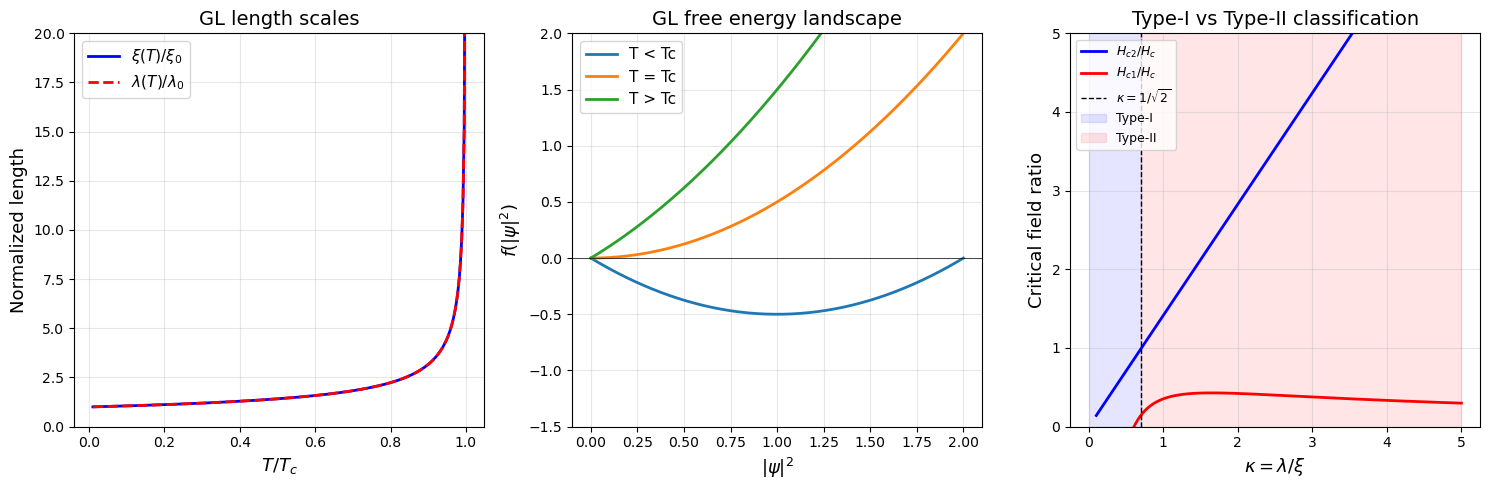

In [2]:
import matplotlib.pyplot as plt

# Temperature-dependent GL coherence length and penetration depth
T_ratio = np.linspace(0.01, 0.999, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Length scales vs temperature
ax = axes[0]
xi_T = 1.0 / np.sqrt(1 - T_ratio)   # xi(T)/xi(0)
lam_T = 1.0 / np.sqrt(1 - T_ratio)  # lambda(T)/lambda(0) (same divergence)
ax.plot(T_ratio, xi_T, 'b-', lw=2, label=r'$\xi(T)/\xi_0$')
ax.plot(T_ratio, lam_T, 'r--', lw=2, label=r'$\lambda(T)/\lambda_0$')
ax.set_xlabel(r'$T/T_c$', fontsize=13)
ax.set_ylabel('Normalized length', fontsize=13)
ax.set_title('GL length scales', fontsize=14)
ax.set_ylim(0, 20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Panel 2: GL free energy landscape f(|psi|^2)
ax = axes[1]
psi2 = np.linspace(0, 2, 300)
for t_label, alpha_sign in [('T < Tc', -1), ('T = Tc', 0), ('T > Tc', 1)]:
    alpha = alpha_sign * 1.0
    beta = 1.0
    f = alpha * psi2 + 0.5 * beta * psi2**2
    ax.plot(psi2, f, lw=2, label=t_label)
ax.set_xlabel(r'$|\psi|^2$', fontsize=13)
ax.set_ylabel(r'$f(|\psi|^2)$', fontsize=13)
ax.set_title('GL free energy landscape', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-1.5, 2)
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

# Panel 3: kappa classification
ax = axes[2]
kappa_vals = np.linspace(0.1, 5, 300)
Hc2_over_Hc = np.sqrt(2) * kappa_vals
Hc1_over_Hc = (np.log(kappa_vals) + 0.5) / (np.sqrt(2) * kappa_vals)
ax.plot(kappa_vals, Hc2_over_Hc, 'b-', lw=2, label=r'$H_{c2}/H_c$')
ax.plot(kappa_vals, Hc1_over_Hc, 'r-', lw=2, label=r'$H_{c1}/H_c$')
ax.axvline(1/np.sqrt(2), color='k', ls='--', lw=1, label=r'$\kappa = 1/\sqrt{2}$')
ax.fill_betweenx([0, 10], 0, 1/np.sqrt(2), alpha=0.1, color='blue', label='Type-I')
ax.fill_betweenx([0, 10], 1/np.sqrt(2), 5, alpha=0.1, color='red', label='Type-II')
ax.set_xlabel(r'$\kappa = \lambda/\xi$', fontsize=13)
ax.set_ylabel('Critical field ratio', fontsize=13)
ax.set_title('Type-I vs Type-II classification', fontsize=14)
ax.set_ylim(0, 5)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

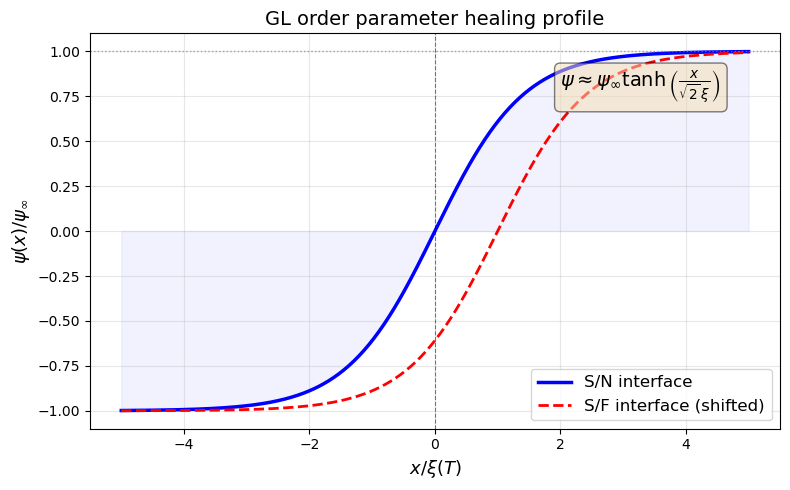

In [3]:
# 1D GL order parameter healing at an S/N interface
x = np.linspace(-5, 5, 500)  # in units of xi(T)

# Solution: psi(x) = psi_0 * tanh(x / (sqrt(2) * xi))
psi_bulk = 1.0
psi_heal = psi_bulk * np.tanh(x / np.sqrt(2))

# Also show the suppressed case (proximity to ferromagnet)
psi_suppressed = psi_bulk * np.tanh((x - 1.0) / np.sqrt(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, psi_heal, 'b-', lw=2.5, label='S/N interface')
ax.plot(x, psi_suppressed, 'r--', lw=2, label='S/F interface (shifted)')
ax.axhline(psi_bulk, color='gray', ls=':', lw=1, alpha=0.7)
ax.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.fill_between(x, 0, psi_heal, alpha=0.05, color='blue')
ax.set_xlabel(r'$x / \xi(T)$', fontsize=13)
ax.set_ylabel(r'$\psi(x) / \psi_\infty$', fontsize=13)
ax.set_title('GL order parameter healing profile', fontsize=14)
ax.annotate(r'$\psi \approx \psi_\infty \tanh\left(\frac{x}{\sqrt{2}\,\xi}\right)$',
            xy=(2, 0.8), fontsize=14, bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Connection to BCS Theory

Gor'kov showed that GL theory can be derived microscopically from BCS theory
near $T_c$. The GL coefficients are related to microscopic parameters:

$$
\alpha = N(0) \frac{T - T_c}{T_c}, \qquad
\beta = \frac{7\zeta(3)}{8\pi^2} \frac{N(0)}{(k_B T_c)^2}
$$

where $N(0)$ is the density of states at the Fermi energy and
$\zeta(3) \approx 1.202$ is the Riemann zeta function.

## References

1. Ginzburg, V.L. & Landau, L.D., "On the theory of superconductivity," Zh. Eksp. Teor. Fiz. **20**, 1064 (1950).
2. Gor'kov, L.P., "Microscopic derivation of the Ginzburg–Landau equations in the theory of superconductivity," Sov. Phys. JETP **9**, 1364 (1959).
3. Tinkham, M., *Introduction to Superconductivity*, 2nd ed. (Dover, 1996).